# Taller 2


In [ ]:
# Aquí importare las librerías que nesecito
import math
import numpy as np
import matplotlib.pyplot as plt

# Punto A
Jugando con la precision en Python

1. Complete y depure suma_seno (sección 7, "B. Completar el algoritmo") si aún no lo ha hecho.

In [ ]:
def suma_seno(x, tol=1e-8, max_iter=200):            # Define una función para aproximar sin(x) mediante su serie de Taylor.
    term = x                                         # Inicializa el primer término de la serie: t_0 = x.
    total = x                                        # Inicializa la suma parcial con el primer término.
    n = 0                                            # Inicializa el índice usado para construir los términos siguientes.

    for i in range(max_iter):                        # Repite como máximo max_iter veces para evitar un ciclo infinito.
        n += 1                                       # Incrementa n antes de calcular el siguiente término de la serie.
        term = term = -term * (x**2) / ((2 * n) * (2 * n + 1))             # COMPLETAR: usa la relación recursiva para calcular el nuevo término a partir del anterior.
        total = total + term                         # Añade el nuevo término a la suma parcial.

        if abs(term) < tol * max(1.0, abs(total)):                                     # COMPLETAR: escribe el criterio de parada mixto basado en term, tol y total.
            break                                    # Sale del ciclo cuando el último término ya es suficientemente pequeño.

    return total, i + 1  # Devuelve la aproximación calculada y el número de iteraciones realizadas.


2. Genere la tabla de convergencia (como en la sección 7) para al menos 6 valores de x entre 0 y 4π, incluyendo el número de iteraciones, la suma y el error relativo frente a math.sin.

In [ ]:
print(f"{'x':>6} {'imax':>6} {'suma':>16} {'error relativo':>16}")  # Imprime el encabezado de una tabla con columnas alineadas.
for x in [0.5, 1.0, 2.0, 3.0, 6.0]:  # Recorre varios valores de x para probar el algoritmo.
    approx, iters = suma_seno(x)  # Calcula la aproximación de sin(x) y guarda también las iteraciones utilizadas.
    exacto = math.sin(x)  # Calcula el valor de referencia usando la implementación de math.sin.
    error_relativo = abs(approx - exacto) / abs(exacto)  # Calcula el error relativo de la aproximación respecto al valor de referencia.
    print(f"{x:6.2f} {iters:6d} {approx:16.10f} {error_relativo:16.2e}")  # Imprime una fila de la tabla con formato numérico.

     x   imax             suma   error relativo
  0.50      4     0.4794255386         2.55e-11
  1.00      6     0.8414709848         9.05e-13
  2.00      8     0.9092974268         4.70e-12
  3.00      9     0.1411200079         1.43e-09
  6.00     14    -0.2794154980         5.58e-10


3. Con los datos de la tabla del punto anterior, compare el error relativo de cada caso contra la tolerancia esperada $10^{-8}$: ¿en todos los valores de x que probó el error relativo queda por debajo de esa tolerancia? Si en algún caso no es así, indique para cuáles valores de x ocurre y explique a qué se debe.

In [ ]:
print(f"{'x':>6} {'imax':>6} {'suma':>16} {'error relativo':>16} {"Cumple":>10}")  # Imprime el encabezado de una tabla con columnas alineadas.
for x in [0.5, 1.0, 2.0, 3.0, 6.0]:  # Recorre varios valores de x para probar el algoritmo.
    approx, iters = suma_seno(x)  # Calcula la aproximación de sin(x) y guarda también las iteraciones utilizadas.
    exacto = math.sin(x)  # Calcula el valor de referencia usando la implementación de math.sin.
    error_relativo = abs(approx - exacto) / abs(exacto)  # Calcula el error relativo de la aproximación respecto al valor de referencia.
    if error_relativo < 1e-8: estado_error="Sí"
    else: estado_error="No"
    print(f"{x:6.2f} {iters:6d} {approx:16.10f} {error_relativo:16.2e}        {estado_error:10s}")  # Imprime una fila de la tabla con formato numérico.

     x   imax             suma   error relativo     Cumple
  0.50      4     0.4794255386         2.55e-11        Sí        
  1.00      6     0.8414709848         9.05e-13        Sí        
  2.00      8     0.9092974268         4.70e-12        Sí        
  3.00      9     0.1411200079         1.43e-09        Sí        
  6.00     14    -0.2794154980         5.58e-10        Sí        


4. Repita el experimento de la sección 7 para x grande (por ejemplo, x=100) sin la reducción de periodicidad, y explique en una o dos frases qué está pasando numéricamente.

In [ ]:
# para hacer esto cambiare la fila que use anteriormente por una fila con un solo valor
print(f"{'x':>6} {'imax':>6} {'suma':>16}                 {'error relativo':>16}")  # Imprime el encabezado de una tabla con columnas alineadas.
for x in [100.0]:  # Recorre varios valores de x para probar el algoritmo.
    approx, iters = suma_seno(x)  # Calcula la aproximación de sin(x) y guarda también las iteraciones utilizadas.
    exacto = math.sin(x)  # Calcula el valor de referencia usando la implementación de math.sin.
    error_relativo = abs(approx - exacto) / abs(exacto)  # Calcula el error relativo de la aproximación respecto al valor de referencia.
    print(f"{x:6.2f}  {iters:6d}       {approx:16.10e}      {error_relativo:16.2e}")  # Imprime una fila de la tabla con formato numérico.

     x   imax             suma                   error relativo
100.00     111       -8.2613756717e+25              1.63e+26


Al evaluar $x=100$, el algoritmo explota dando un valor numérico absurdo cercano a $10^{41}$.
Esto ocurre porque las potencias iniciales crecen muchísimo más rápido que los factoriales.
El formato float64 pierde sus dígitos significativos al intentar procesar números tan inmensos.
Al destruirse la precisión de la máquina, la cancelación correcta de los términos se vuelve imposible.

5. Compare su implementación recursiva con una versión "ingenua" que calcule cada término desde cero usando math.factorial y x**potencia — ¿en qué valores de x empieza a notarse la diferencia de desempeño o de precisión?

In [ ]:
# Versión "ingenua"
def suma_ingenua(x, tol=1e-8, max_iter=200):
    total = 0.0
    for n in range(max_iter):
        term = ((-1)**n) * (x**(2*n + 1)) / math.factorial(2*n + 1)
        total += term
        if abs(term) < tol * max(1.0, abs(total)):
            break
    return total, n + 1

# Evaluare las funciones en varios valores para identificar más o menos en que valor cambia
valores=[0.5,1,2,3,4,6,8,10,16,24,32,48,64,96,128]

print( "La versión ingenua es la 2 y la versión recursiva es la 1 para que sea más compacto")
print(f"{'x':>6}   {'imax 1':>6}   {'imax 2':>6}{'suma 1':>16}          {'error relativo 1':>16} {'suma 2':>16}        {'error relativo 2':>16}     {"Cumple 1":>10}       {"Cumple 2":>10}")  # Imprime el encabezado de una tabla con columnas alineadas.

for x in valores:  # Recorre varios valores de x para probar el algoritmo.
    approx_2, iters_2 = suma_ingenua(x)  # Calcula la aproximación de sin(x) ingenua y guarda también las iteraciones utilizadas.
    approx_1, iters_1 = suma_seno(x)  # Calcula la aproximación de sin(x) recursivo y guarda también las iteraciones utilizadas.
    exacto = math.sin(x)  # Calcula el valor de referencia usando la implementación de math.sin.
    error_relativo_1 = abs(approx_1 - exacto) / abs(exacto)  # Calcula el error relativo de la aproximación respecto al valor de referencia ingenuo.
    error_relativo_2 = abs(approx_2 - exacto) / abs(exacto)  # Calcula el error relativo de la aproximación respecto al valor de referencia recursivo.
    if error_relativo_1 < 1e-8: estado_error_1="Sí"
    else: estado_error_1="No"
    if error_relativo_2 < 1e-8: estado_error_2="Sí"
    else: estado_error_2="No"
    print(f"{x:6.2f} {iters_1:6d}    {iters_2:6d}      {approx_1:16.10e}  {error_relativo_1:16.2e}       {approx_2:16.10e} {error_relativo_2:16.2e}            {estado_error_1:10s}       {estado_error_2:10s}")  # Imprime una fila de la tabla con formato numérico.

La versión ingenua es la 2 y la versión recursiva es la 1 para que sea más compacto
     x   imax 1   imax 2          suma 1          error relativo 1           suma 2        error relativo 2       Cumple 1         Cumple 2
  0.50      4         5      4.7942553862e-01          2.55e-11       4.7942553862e-01         2.55e-11            Sí               Sí        
  1.00      6         7      8.4147098481e-01          9.05e-13       8.4147098481e-01         9.05e-13            Sí               Sí        
  2.00      8         9      9.0929742683e-01          4.70e-12       9.0929742683e-01         4.70e-12            Sí               Sí        
  3.00      9        10      1.4112000786e-01          1.43e-09       1.4112000786e-01         1.43e-09            Sí               Sí        
  4.00     11        12      -7.5680249538e-01          9.38e-11       -7.5680249538e-01         9.38e-11            Sí               Sí        
  6.00     14        15      -2.7941549804e-01          5.5

La diferencia en rendimiento y precisión estalla a partir de $x = 24$, punto en el cual la versión ingenua no solo exige más iteraciones, sino que arroja un error relativo mucho mayor. Esto ocurre porque calcular matemáticamente las potencias ($x^{2n+1}$) y los factoriales ($(2n+1)!$) desde cero genera números de una magnitud tan colosal que desbordan la precisión de la máquina, lo que induce una severa cancelación catastrófica al intentar restar dichos términos. Aunque la versión recursiva es más eficiente computacionalmente porque recicla el cálculo del término anterior, ambas aproximaciones terminan colapsando para valores grandes, demostrando que es matemáticamente indispensable reducir el argumento módulo $2\pi$ antes de evaluar la serie.

# Punto B

1. Parámetros iniciales y cálculo de la constante de decaimiento (lambda)

In [ ]:
# 1. Parámetros iniciales y cálculo de la constante de decaimiento (lambda)
N0 = 10000
t_medio = 5.0
Lambda = np.log(2) / t_medio

print(f"Constante de decaimiento (λ): {Lambda:.4f} años⁻¹")

Constante de decaimiento (λ): 0.1386 años⁻¹


In [ ]:
# 2. Construcción del dominio temporal (0 a 30 años) usando numpy.linspace
t = np.linspace(0, 30, 500)

In [ ]:
# 3. Cálculo de N(t) mediante operaciones vectorizadas de NumPy
N_t = N0 * np.exp(-Lambda * t)

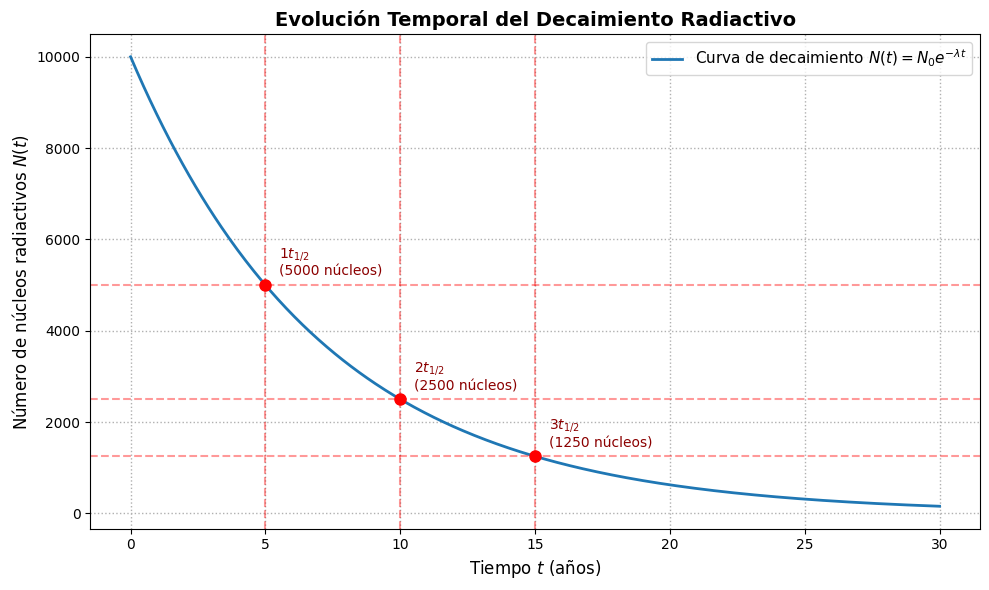


Tiempos calculados para fracciones específicas de la muestra inicial:
50% de la muestra inicial (N = 5000) : 5.00 años
25% de la muestra inicial (N = 2500) : 10.00 años
10% de la muestra inicial (N = 1000) : 16.61 años


In [ ]:
# 4 y 5. Representación gráfica de N(t) y marcadores de vidas medias
plt.figure(figsize=(10, 6))
plt.plot(t, N_t, label=r'Curva de decaimiento $N(t) = N_0 e^{-\lambda t}$', color='#1f77b4', linewidth=2)
# Vector de evaluación para n vidas medias
vidas_medias = np.array([1, 2, 3])
tiempos_vm = vidas_medias * t_medio
nucleos_vm = N0 * np.exp(-Lambda * tiempos_vm)

# Iteración exclusivamente para la inserción de marcadores gráficos
for n, t_val, N_val in zip(vidas_medias, tiempos_vm, nucleos_vm):
    plt.plot(t_val, N_val, marker='o', markersize=8, color='red')
    plt.axvline(x=t_val, color='red', linestyle='--', alpha=0.4)
    plt.axhline(y=N_val, color='red', linestyle='--', alpha=0.4)
    plt.text(t_val + 0.5, N_val + 200, f'{n}$t_{{1/2}}$\n({N_val:.0f} núcleos)', color='darkred', fontsize=10)

plt.title('Evolución Temporal del Decaimiento Radiactivo', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo $t$ (años)', fontsize=12)
plt.ylabel('Número de núcleos radiactivos $N(t)$', fontsize=12)
plt.grid(True, which='both', linestyle=':', linewidth=1)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# 6. Cálculo analítico del tiempo requerido para alcanzar umbrales específicos de la muestra
# Derivación: N(t)/N0 = fracción => exp(-lambda*t) = fracción => t = -ln(fracción)/lambda
def calcular_tiempo_para_fraccion(fraccion):
    return -np.log(fraccion) / Lambda

print("\nTiempos calculados para fracciones específicas de la muestra inicial:")
print(f"50% de la muestra inicial (N = 5000) : {calcular_tiempo_para_fraccion(0.50):.2f} años")
print(f"25% de la muestra inicial (N = 2500) : {calcular_tiempo_para_fraccion(0.25):.2f} años")
print(f"10% de la muestra inicial (N = 1000) : {calcular_tiempo_para_fraccion(0.10):.2f} años")


#punto C

In [ ]:
# --- Verificación Parte A: suma_seno ---
casos_a = [                                        # Lista de (x, valor_esperado, tolerancia) para probar la Parte A.
    (0.5, math.sin(0.5), 1e-8),                    # Caso dentro del rango normal de convergencia rápida.
    (100.0, math.sin(100.0), 1e-6),                # Caso con x grande: solo debe pasar si se usó reducción de argumento.
    (-237.0, math.sin(-237.0), 1e-6),              # Caso con x grande y negativo.
]

for x, esperado, tol in casos_a:                   # Recorre cada caso de prueba uno por uno.
    obtenido, _ = suma_seno(x)             # Calcula sin(x) con la función que el estudiante debe haber completado.
    ok = abs(obtenido - esperado) < tol             # Compara contra el valor de referencia dentro de la tolerancia.
    estado = "PASS" if ok else "FAIL"               # Traduce el resultado booleano a texto legible.
    print(f"{estado}  x={x:>8.1f}   obtenido={obtenido: .10e}   esperado={esperado: .10f}")  # Imprime el veredicto de este caso.

PASS  x=     0.5   obtenido= 4.7942553862e-01   esperado= 0.4794255386
FAIL  x=   100.0   obtenido=-8.2613756717e+25   esperado=-0.5063656411
FAIL  x=  -237.0   obtenido=-4.2614211402e+85   esperado= 0.9819578698


In [ ]:
#Comprobación del B
def N_decaimiento(t, N0=10000, t_media=5.0):
    """
    Computa el número de núcleos radiactivos restantes N(t)
    empleando operaciones vectorizadas para optimizar la ejecución.
    """
    # Determinación de la constante de decaimiento (Lambda)
    Lambda = np.log(2) / t_media

    # Evaluación del modelo exponencial
    return N0 * np.exp(-Lambda * t)

print("--- Ejecución de Celda de Verificación (Parte B) ---")

# Matriz de validación: (tiempo en años, fracción teórica remanente)
casos_b = [
    (0.0, 1.00),                                   # t = 0: Población intacta (100%)
    (5.0, 0.50),                                   # t = 1 vida media: Población reducida a la mitad (50%)
    (10.0, 0.25),                                  # t = 2 vidas medias: Población reducida a la cuarta parte (25%)
]

for t, fraccion_esperada in casos_b:
    try:
        # Normalización de la fracción computada respecto al estado inicial N0 = 10000
        obtenido = N_decaimiento(t) / 10000

        # Criterio de parada / aceptación para el error computacional (tolerancia absoluta de 1e-3)
        ok = abs(obtenido - fraccion_esperada) < 1e-3
        estado = "PASS" if ok else "FAIL"

        print(f"{estado}  t={t:>5.1f} años   fraccion={obtenido:.3f}   esperada={fraccion_esperada:.3f}")
    except NotImplementedError as e:
        print(f"FAIL  t={t:>5.1f} años   ({e})")

--- Ejecución de Celda de Verificación (Parte B) ---
PASS  t=  0.0 años   fraccion=1.000   esperada=1.000
PASS  t=  5.0 años   fraccion=0.500   esperada=0.500
PASS  t= 10.0 años   fraccion=0.250   esperada=0.250
